# Weather-centre reference maps with `add_reference_map`

Dressing a georeferenced `ArrayGlyph` in the clean look of an operational weather-centre chart (ECMWF /
Magics style: grey coastlines, a dashed lon/lat graticule, degree labels, a subtle frame) used to take a
dozen-plus lines of matplotlib after `plot()`. `add_reference_map` collapses that recipe into one call.

It is a thin **preset** over the existing `add_features` Natural Earth layers, so it needs no `cartopy` — just
the `cleopatra[tiles]` extra for the reference data. Because it draws in the axes' geographic coordinates, the
glyph must be **georeferenced**: pass `extent=[west, south, east, north]` (or construct the glyph with
`extent=`). Deriving that extent from a source dataset is the caller's job — cleopatra renders the
coordinates it is given.

In [1]:
%matplotlib inline
import warnings

import matplotlib.pyplot as plt
import numpy as np

from cleopatra.array_glyph import ArrayGlyph
from cleopatra.geo import available_map_styles

warnings.filterwarnings("ignore")  # keep the embedded outputs lean
available_map_styles()

['ecmwf', 'ecmwf-dark']

## A georeferenced field

We build a smooth synthetic field over the US East Coast / western Atlantic and give the glyph its geographic
`extent` as `[west, south, east, north]`. On its own it is just a coloured grid — no geography yet.

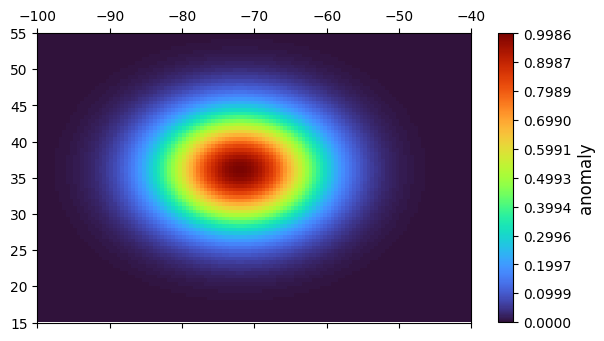

In [2]:
west, south, east, north = -100.0, 15.0, -40.0, 55.0
lat = np.linspace(south, north, 80)
lon = np.linspace(west, east, 120)
lon2d, lat2d = np.meshgrid(lon, lat)

# a smooth anomaly, just so there is something to look at
field = np.exp(-(((lon2d + 72) ** 2) / 120.0 + ((lat2d - 34) ** 2) / 60.0))

glyph = ArrayGlyph(field, extent=[west, south, east, north], figsize=(7, 5))
glyph.plot(cmap="turbo", cbar_label="anomaly")
plt.show()

## One call for the ECMWF look

`add_reference_map("ecmwf")` overlays grey coastlines + borders, a dashed graticule, `°W`/`°N` labels and a
subtle frame. It returns the axes for chaining.

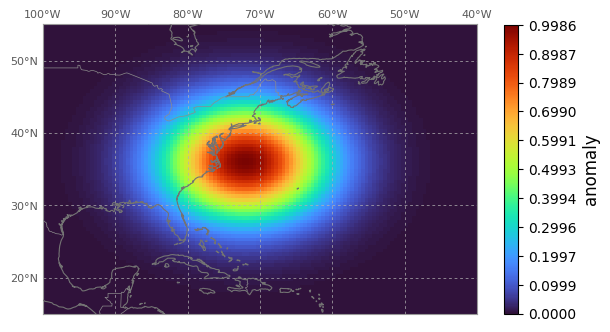

In [3]:
glyph = ArrayGlyph(field, extent=[west, south, east, north], figsize=(7, 5))
glyph.plot(cmap="turbo", cbar_label="anomaly")
glyph.add_reference_map("ecmwf")
plt.show()

### What it replaces

Without the preset, every notebook re-derived the same recipe by hand:

```python
ax = glyph.ax
glyph.add_features("coastline", "50m", colors="0.45", linewidths=0.8, zorder=5)
glyph.add_features("borders",   "50m", colors="0.55", linewidths=0.5, zorder=5)
from matplotlib.ticker import MultipleLocator, FuncFormatter
ax.xaxis.set_major_locator(MultipleLocator(10)); ax.yaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{abs(v):.0f}°W"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0f}°N"))
ax.grid(True, color="0.7", linestyle=(0, (4, 4)), linewidth=0.5, zorder=4)
ax.tick_params(colors="0.35", labelsize=8, length=0)
for sp in ax.spines.values(): sp.set_edgecolor("0.6"); sp.set_linewidth(0.8)
```

## Dark backgrounds

ECMWF's mid-grey is tuned for light backgrounds; over a dark field (e.g. a satellite true-colour RGB) it
vanishes. The `"ecmwf-dark"` preset uses lighter greys, and `style="auto"` picks between the two from the
background luminance. Here is a mostly-dark RGB scene:

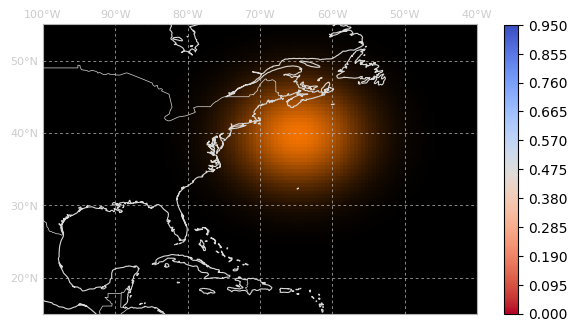

In [4]:
h, w = 80, 120
yy, xx = np.mgrid[0:h, 0:w]
blob = np.exp(-(((xx - 70) ** 2) / 300.0 + ((yy - 30) ** 2) / 200.0))
rgb = np.zeros((h, w, 3))
rgb[..., 0] = 0.95 * blob  # a warm bright feature on a near-black scene
rgb[..., 1] = 0.45 * blob

glyph = ArrayGlyph(rgb, extent=[west, south, east, north], figsize=(7, 5))
glyph.plot()
glyph.add_reference_map("auto")  # -> ecmwf-dark, light-grey coastlines
plt.show()

## Tuning

Override the graticule spacing with `graticule_step`, the coastline detail with `resolution`, or start from
the `cleopatra.geo.REFERENCE_MAP_STYLES` table for a fully custom preset. Pass `ax=` to decorate a specific
axes.

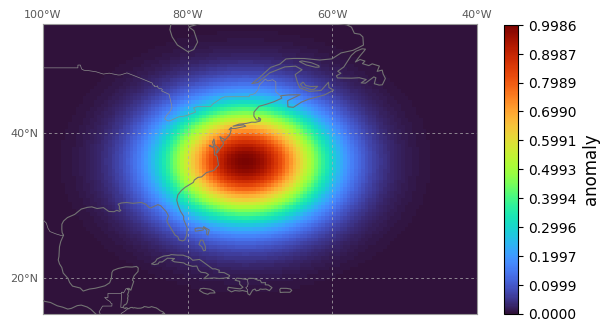

In [5]:
glyph = ArrayGlyph(field, extent=[west, south, east, north], figsize=(7, 5))
glyph.plot(cmap="turbo", cbar_label="anomaly")
glyph.add_reference_map("ecmwf", graticule_step=20, resolution="110m")
plt.show()